# Лабораторная 1: Классификация цвета автомобиля

In [1]:
# !pip install torch torchvision pandas scikit-learn pillow tqdm matplotlib

In [2]:
from pathlib import Path
from collections import Counter
import random

import pandas as pd
from IPython.display import display
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DATA_ROOT = Path('confirmed_fronts')
MIN_SAMPLES_PER_CLASS = 1000
DROP_COLORS = {'multicolour', 'multicolor', 'unlisted'}

IMG_SIZE = 80
BATCH_SIZE = 32

DEVICE = torch.device('mps')

print(f'Device: {DEVICE}')
print(f'IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}')

Device: mps
IMG_SIZE=80, BATCH_SIZE=32


In [3]:
def parse_filename(path: Path):
    # Brand$$Model$$Year$$Color$$ModelId$$InstanceId$$image_k.jpg
    parts = path.name.split('$$')
    if len(parts) < 6:
        return None
    return {
        'path': str(path),
        'brand': parts[0],
        'model': parts[1],
        'year': parts[2],
        'color': parts[3],
        'model_id': parts[4],
        'instance_id': parts[5],
    }

rows = []
for p in DATA_ROOT.rglob('*.jpg'):
    rec = parse_filename(p)
    if rec is not None:
        rows.append(rec)

df = pd.DataFrame(rows)
print(f'Total images found: {len(df):,}')
print(f'Total raw classes (colors): {df["color"].nunique()}')

Total images found: 61,827
Total raw classes (colors): 23


In [ ]:
df_filtered = df[~df['color'].str.lower().isin(DROP_COLORS)].copy()

color_counts = df_filtered['color'].value_counts()
kept_colors = color_counts[color_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
df_filtered = df_filtered[df_filtered['color'].isin(kept_colors)].copy()

final_counts = df_filtered['color'].value_counts().sort_values(ascending=False)
print('Class distribution:')
display(final_counts.to_frame('count'))
print(f'Total images: {len(df_filtered):,}')
print(f'Total classes: {len(final_counts)}')

Class distribution:


,count
color,
Black,14317
Grey,9474
White,9395
Blue,8483
Silver,7770
Red,6095


Total images: 55,534
Total classes: 6


In [5]:
color_to_idx = {c: i for i, c in enumerate(sorted(df_filtered['color'].unique()))}
idx_to_color = {i: c for c, i in color_to_idx.items()}

df_filtered['label'] = df_filtered['color'].map(color_to_idx)

train_df, val_df = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=SEED,
    stratify=df_filtered['label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'Train size: {len(train_df):,}')
print(f'Val size: {len(val_df):,}')
print('Label map:', color_to_idx)

Train size: 44,427
Val size: 11,107
Label map: {'Black': 0, 'Blue': 1, 'Grey': 2, 'Red': 3, 'Silver': 4, 'White': 5}


In [ ]:
from tqdm import tqdm

class DVMColorDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = int(row['label'])

        if self.transform is not None:
            image = self.transform(image)

        return image, label
    

def compute_rgb_stats(frame: pd.DataFrame, img_size: int):
    paths = frame['path'].tolist()

    resize = transforms.Resize((img_size, img_size))
    channel_sum = torch.zeros(3, dtype=torch.float64)
    channel_sq_sum = torch.zeros(3, dtype=torch.float64)
    total_pixels = 0

    n = len(paths)
    progress = tqdm(paths, total=n, desc='RGB stats', leave=True)
    for path in progress:
        image = Image.open(path).convert('RGB')
        image = resize(image)
        tensor = transforms.functional.to_tensor(image).to(torch.float64)

        channel_sum += tensor.sum(dim=(1, 2))
        channel_sq_sum += (tensor * tensor).sum(dim=(1, 2))
        total_pixels += tensor.shape[1] * tensor.shape[2]

    mean = channel_sum / total_pixels
    var = (channel_sq_sum / total_pixels) - (mean * mean)
    std = torch.sqrt(var.clamp(min=1e-12))
    return mean.to(torch.float32), std.to(torch.float32), n


print('Computing dataset RGB stats for normalization', flush=True)
train_mean, train_std, used_n = compute_rgb_stats(train_df, img_size=IMG_SIZE)

norm_mean = [float(x) for x in train_mean.tolist()]
norm_std = [float(x) for x in train_std.tolist()]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std),
])

train_ds = DVMColorDataset(train_df, transform=train_transform)
val_ds = DVMColorDataset(val_df, transform=val_transform)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

xb, yb = next(iter(train_loader))
print('One batch:', xb.shape, yb.shape)

Computing dataset RGB stats for normalization...


RGB stats: 100%|██████████| 44427/44427 [00:23<00:00, 1863.12it/s]


Used images for stats: 44427
Normalization mean: [0.667255, 0.667421, 0.684328]
Normalization std: [0.350423, 0.348876, 0.339481]
One batch: torch.Size([32, 3, 80, 80]) torch.Size([32])


In [7]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = [block(self.in_channels, out_channels, stride=stride)]
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def build_resnet18(num_classes):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


In [8]:
num_classes = len(color_to_idx)
model = build_resnet18(num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model.__class__.__name__)
print(f'Num classes: {num_classes}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


ResNet
Num classes: 6
Trainable params: 11,179,590


In [ ]:
model.eval()
with torch.no_grad():
    xb = xb.to(DEVICE)
    logits = model(xb)

print('Input batch:', xb.shape)
print('Logits shape:', logits.shape)
assert logits.shape == (xb.shape[0], num_classes)


Input batch: torch.Size([32, 3, 80, 80])
Logits shape: torch.Size([32, 6])
Forward pass OK


## Обучение кастомной ResNet

In [ ]:
from sklearn.metrics import f1_score
import time

SCRATCH_EPOCHS = 6
SCRATCH_LR = 1e-3
SCRATCH_WEIGHT_DECAY = 1e-4

SCRATCH_RESUME = True
SCRATCH_SAVE_EVERY_EPOCH = True

CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SCRATCH_CKPT_PATH = CHECKPOINT_DIR / 'best_resnet_scratch.pth'
SCRATCH_LAST_CKPT_PATH = CHECKPOINT_DIR / 'last_resnet_scratch.pth'

print('Scratch best checkpoint:', SCRATCH_CKPT_PATH.resolve())
print('Scratch last checkpoint:', SCRATCH_LAST_CKPT_PATH.resolve())


Scratch best checkpoint: /Users/brrdlam/ct-itmo/ct-computer-vision/lab1/checkpoints/best_resnet_scratch.pth
Scratch last checkpoint: /Users/brrdlam/ct-itmo/ct-computer-vision/lab1/checkpoints/last_resnet_scratch.pth
SCRATCH_RESUME: True


In [ ]:
from tqdm import tqdm


def to_cpu(obj):
    if torch.is_tensor(obj):
        return obj.detach().cpu()
    if isinstance(obj, dict):
        return {k: to_cpu(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_cpu(v) for v in obj]
    if isinstance(obj, tuple):
        return tuple(to_cpu(v) for v in obj)
    return obj


def evaluate_resnet_scratch(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            y_true.extend(yb.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    avg_loss = total_loss / max(len(loader.dataset), 1)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = (torch.tensor(y_true) == torch.tensor(y_pred)).float().mean().item()
    return avg_loss, macro_f1, acc


def train_custom_resnet_scratch(epochs: int = SCRATCH_EPOCHS, resume: bool = SCRATCH_RESUME):
    model = build_resnet18(num_classes=len(color_to_idx)).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=SCRATCH_LR, weight_decay=SCRATCH_WEIGHT_DECAY)

    history = []
    best_f1 = -1.0
    best_epoch = -1
    start_epoch = 1

    if SCRATCH_CKPT_PATH.exists():
        best_ckpt = torch.load(SCRATCH_CKPT_PATH, map_location='cpu')
        best_f1 = float(best_ckpt.get('best_val_f1_macro', best_f1))
        best_epoch = int(best_ckpt.get('best_epoch', best_epoch))

    if resume and SCRATCH_LAST_CKPT_PATH.exists():
        last = torch.load(SCRATCH_LAST_CKPT_PATH, map_location='cpu')
        model.load_state_dict(last['model_state_dict'])
        if 'optimizer_state_dict' in last:
            optimizer.load_state_dict(last['optimizer_state_dict'])
        history = list(last.get('history', []))
        start_epoch = int(last.get('epoch', 0)) + 1
        best_f1 = float(last.get('best_val_f1_so_far', best_f1))
        best_epoch = int(last.get('best_epoch_so_far', best_epoch))
        print(f'[resnet_scratch] resume from {SCRATCH_LAST_CKPT_PATH}, start_epoch={start_epoch}', flush=True)

    if start_epoch > epochs:
        print('[resnet_scratch] nothing to train: increase SCRATCH_EPOCHS', flush=True)
        if not SCRATCH_CKPT_PATH.exists() and SCRATCH_LAST_CKPT_PATH.exists():
            last = torch.load(SCRATCH_LAST_CKPT_PATH, map_location='cpu')
            torch.save({
                'model_name': 'resnet_scratch',
                'model_state_dict': last['model_state_dict'],
                'best_epoch': int(last.get('best_epoch_so_far', last.get('epoch', -1))),
                'best_val_f1_macro': float(last.get('best_val_f1_so_far', last.get('val_f1_macro', -1.0))),
                'color_to_idx': color_to_idx,
                'idx_to_color': idx_to_color,
            }, SCRATCH_CKPT_PATH)
        return pd.DataFrame(history)

    for epoch in range(start_epoch, epochs + 1):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        seen = 0

        bar = tqdm(train_loader, total=len(train_loader), desc=f'resnet_scratch e{epoch}/{epochs}', leave=True)
        for step, (xb, yb) in enumerate(bar, start=1):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            seen += xb.size(0)

            bar.set_postfix(step=f'{step}/{len(train_loader)}', batch_loss=f'{loss.item():.4f}')

        train_loss = running_loss / max(seen, 1)

        print('[resnet_scratch] validation on CPU', flush=True)
        eval_model = build_resnet18(num_classes=len(color_to_idx)).to('cpu')
        eval_model.load_state_dict(to_cpu(model.state_dict()))
        cpu_criterion = nn.CrossEntropyLoss()
        val_loss, val_f1, val_acc = evaluate_resnet_scratch(eval_model, val_loader, cpu_criterion, torch.device('cpu'))

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_f1_macro': val_f1,
            'val_accuracy': val_acc,
        })

        print(
            f'[resnet_scratch] epoch {epoch}/{epochs} | train_loss={train_loss:.4f} | '
            f'val_loss={val_loss:.4f} | val_f1={val_f1:.4f} | val_acc={val_acc:.4f} | '
            f'time={time.time() - epoch_start:.1f}s',
            flush=True,
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save({
                'model_name': 'resnet_scratch',
                'model_state_dict': to_cpu(model.state_dict()),
                'best_epoch': int(best_epoch),
                'best_val_f1_macro': float(best_f1),
                'color_to_idx': color_to_idx,
                'idx_to_color': idx_to_color,
            }, SCRATCH_CKPT_PATH)

        epoch_payload = {
            'model_name': 'resnet_scratch',
            'epoch': epoch,
            'model_state_dict': to_cpu(model.state_dict()),
            'optimizer_state_dict': to_cpu(optimizer.state_dict()),
            'train_loss': float(train_loss),
            'val_loss': float(val_loss),
            'val_f1_macro': float(val_f1),
            'val_accuracy': float(val_acc),
            'best_val_f1_so_far': float(best_f1),
            'best_epoch_so_far': int(best_epoch),
            'color_to_idx': color_to_idx,
            'idx_to_color': idx_to_color,
            'history': history,
        }

        torch.save(epoch_payload, SCRATCH_LAST_CKPT_PATH)
        if SCRATCH_SAVE_EVERY_EPOCH:
            torch.save(epoch_payload, CHECKPOINT_DIR / f'resnet_scratch_epoch_{epoch:02d}.pth')

    print(f'Saved best scratch checkpoint: {SCRATCH_CKPT_PATH}', flush=True)
    return pd.DataFrame(history)



In [ ]:
scratch_history_df = train_custom_resnet_scratch(epochs=SCRATCH_EPOCHS)
display(scratch_history_df)

[resnet_scratch] resume from checkpoints/last_resnet_scratch.pth, start_epoch=7
[resnet_scratch] nothing to train: increase SCRATCH_EPOCHS


,epoch,train_loss,val_loss,val_f1_macro,val_accuracy
0,1,0.669720,0.508553,0.826223,0.819393
1,2,0.480273,0.504856,0.818545,0.822184
2,3,0.425177,0.404745,0.861251,0.859278
3,4,0.377404,0.412651,0.859074,0.856127
4,5,0.348697,0.345716,0.882092,0.878545
5,6,0.318252,0.429912,0.853115,0.840461


## Задание 2: Дообучение 2 предобученных классификаторов

В этом разделе дообучаются две модели, предобученные на ImageNet, на одинаково предобработанном сплите DVM, затем они сравниваются по `F1_macro`.


In [ ]:
from torchvision import models

PRETRAINED_MODEL_NAMES = ['resnet18', 'shufflenet_v2_x1_0']

FINETUNE_EPOCHS = 6
FINETUNE_LR = 1e-4
FINETUNE_WEIGHT_DECAY = 1e-4

TRAIN_HEAD_ONLY = False

PRETRAIN_RESUME = True
PRETRAIN_SAVE_EVERY_EPOCH = True

CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print('Models:', PRETRAINED_MODEL_NAMES)

Models: ['resnet18', 'shufflenet_v2_x1_0']
TRAIN_HEAD_ONLY: False
PRETRAIN_RESUME: True


In [14]:
def load_pretrained_weights(factory, weights_enum_name: str):
    if hasattr(models, weights_enum_name):
        weights_enum = getattr(models, weights_enum_name)
        return factory(weights=weights_enum.DEFAULT)
    return factory(pretrained=True)


def build_pretrained_model(model_name: str, num_classes: int) -> nn.Module:
    if model_name == 'resnet18':
        model = load_pretrained_weights(models.resnet18, 'ResNet18_Weights')
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        return model

    if model_name == 'shufflenet_v2_x1_0':
        model = load_pretrained_weights(models.shufflenet_v2_x1_0, 'ShuffleNet_V2_X1_0_Weights')
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        return model

    raise ValueError(f'Unsupported model_name: {model_name}')


def set_trainable_layers(model: nn.Module, model_name: str, train_head_only: bool):
    if not train_head_only:
        for p in model.parameters():
            p.requires_grad = True
        return

    for p in model.parameters():
        p.requires_grad = False

    if model_name in {'resnet18', 'shufflenet_v2_x1_0'}:
        for p in model.fc.parameters():
            p.requires_grad = True
        return

    raise ValueError(f'Unsupported model_name: {model_name}')


In [ ]:
import time
from tqdm import tqdm


def to_cpu(obj):
    if torch.is_tensor(obj):
        return obj.detach().cpu()
    if isinstance(obj, dict):
        return {k: to_cpu(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_cpu(v) for v in obj]
    if isinstance(obj, tuple):
        return tuple(to_cpu(v) for v in obj)
    return obj


def evaluate_classifier(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            y_true.extend(yb.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    avg_loss = total_loss / max(len(loader.dataset), 1)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = (torch.tensor(y_true) == torch.tensor(y_pred)).float().mean().item()
    return avg_loss, macro_f1, acc


def finetune_pretrained_model(model_name: str, epochs: int = FINETUNE_EPOCHS, resume: bool = PRETRAIN_RESUME):
    model = build_pretrained_model(model_name, num_classes=len(color_to_idx)).to(DEVICE)
    set_trainable_layers(model, model_name=model_name, train_head_only=TRAIN_HEAD_ONLY)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=FINETUNE_LR, weight_decay=FINETUNE_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    history = []
    best_f1 = -1.0
    best_epoch = -1
    start_epoch = 1

    best_ckpt_path = CHECKPOINT_DIR / f'best_{model_name}.pth'
    last_ckpt_path = CHECKPOINT_DIR / f'last_{model_name}.pth'

    if best_ckpt_path.exists():
        best_ckpt = torch.load(best_ckpt_path, map_location='cpu')
        best_f1 = float(best_ckpt.get('best_val_f1_macro', best_f1))
        best_epoch = int(best_ckpt.get('best_epoch', best_epoch))

    if resume and last_ckpt_path.exists():
        last = torch.load(last_ckpt_path, map_location='cpu')
        model.load_state_dict(last['model_state_dict'])
        if 'optimizer_state_dict' in last:
            optimizer.load_state_dict(last['optimizer_state_dict'])
        history = list(last.get('history', []))
        start_epoch = int(last.get('epoch', 0)) + 1
        best_f1 = float(last.get('best_val_f1_so_far', best_f1))
        best_epoch = int(last.get('best_epoch_so_far', best_epoch))
        print(f'[{model_name}] resume from {last_ckpt_path}, start_epoch={start_epoch}', flush=True)

    if start_epoch > epochs:
        print(f'[{model_name}] nothing to train: increase FINETUNE_EPOCHS', flush=True)
        return {
            'model_name': model_name,
            'best_epoch': best_epoch,
            'best_val_f1_macro': best_f1,
            'checkpoint_path': str(best_ckpt_path),
            'history_df': pd.DataFrame(history),
        }

    for epoch in range(start_epoch, epochs + 1):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        seen = 0

        bar = tqdm(train_loader, total=len(train_loader), desc=f'{model_name} e{epoch}/{epochs}', leave=True, dynamic_ncols=True)
        for step, (xb, yb) in enumerate(bar, start=1):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            seen += xb.size(0)

            bar.set_postfix(step=f'{step}/{len(train_loader)}', batch_loss=f'{loss.item():.4f}')

        train_loss = running_loss / max(seen, 1)

        print(f'[{model_name}] validation on CPU', flush=True)
        eval_model = build_pretrained_model(model_name, num_classes=len(color_to_idx)).to('cpu')
        eval_model.load_state_dict(to_cpu(model.state_dict()))
        cpu_criterion = nn.CrossEntropyLoss()
        val_loss, val_f1, val_acc = evaluate_classifier(eval_model, val_loader, cpu_criterion, torch.device('cpu'))

        history.append({
            'model_name': model_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_f1_macro': val_f1,
            'val_accuracy': val_acc,
        })

        print(
            f'[{model_name}] epoch {epoch}/{epochs} | train_loss={train_loss:.4f} | '
            f'val_loss={val_loss:.4f} | val_f1={val_f1:.4f} | val_acc={val_acc:.4f} | '
            f'time={time.time() - epoch_start:.1f}s',
            flush=True,
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save({
                'model_name': model_name,
                'model_state_dict': to_cpu(model.state_dict()),
                'best_epoch': int(best_epoch),
                'best_val_f1_macro': float(best_f1),
                'color_to_idx': color_to_idx,
                'idx_to_color': idx_to_color,
                'train_head_only': TRAIN_HEAD_ONLY,
            }, best_ckpt_path)

        epoch_payload = {
            'model_name': model_name,
            'epoch': epoch,
            'model_state_dict': to_cpu(model.state_dict()),
            'optimizer_state_dict': to_cpu(optimizer.state_dict()),
            'train_loss': float(train_loss),
            'val_loss': float(val_loss),
            'val_f1_macro': float(val_f1),
            'val_accuracy': float(val_acc),
            'best_val_f1_so_far': float(best_f1),
            'best_epoch_so_far': int(best_epoch),
            'color_to_idx': color_to_idx,
            'idx_to_color': idx_to_color,
            'train_head_only': TRAIN_HEAD_ONLY,
            'history': history,
        }

        torch.save(epoch_payload, last_ckpt_path)
        if PRETRAIN_SAVE_EVERY_EPOCH:
            torch.save(epoch_payload, CHECKPOINT_DIR / f'{model_name}_epoch_{epoch:02d}.pth')

    return {
        'model_name': model_name,
        'best_epoch': best_epoch,
        'best_val_f1_macro': best_f1,
        'checkpoint_path': str(best_ckpt_path),
        'history_df': pd.DataFrame(history),
    }



In [16]:
all_results = []
all_histories = {}

for model_name in PRETRAINED_MODEL_NAMES:
    print('=' * 80, flush=True)
    print(f'Training model: {model_name}', flush=True)
    result = finetune_pretrained_model(model_name, epochs=FINETUNE_EPOCHS)
    all_histories[model_name] = result['history_df']
    all_results.append({
        'model_name': result['model_name'],
        'best_epoch': result['best_epoch'],
        'best_val_f1_macro': result['best_val_f1_macro'],
        'checkpoint_path': result['checkpoint_path'],
        'source': 'trained_now',
    })

comparison_df = pd.DataFrame(all_results).sort_values('best_val_f1_macro', ascending=False).reset_index(drop=True)
display(comparison_df)

best_row = comparison_df.iloc[0]
print(
    f'Best pretrained classifier: {best_row["model_name"]} '
    f'(best val F1_macro={best_row["best_val_f1_macro"]:.4f}, epoch={int(best_row["best_epoch"])})'
)


Training model: resnet18
[resnet18] resume from checkpoints/last_resnet18.pth, start_epoch=4


resnet18 e4/6: 100%|██████████| 1389/1389 [01:31<00:00, 15.17it/s, batch_loss=0.5253, step=1389/1389]

[resnet18] validation on CPU (stability mode)


[resnet18] epoch 4/6 | train_loss=0.1927 | val_loss=0.2946 | val_f1=0.9038 | val_acc=0.9003 | time=172.1s


resnet18 e5/6: 100%|██████████| 1389/1389 [01:26<00:00, 15.97it/s, batch_loss=0.1741, step=1389/1389]

...

shufflenet_v2_x1_0 e6/6: 100%|██████████| 1389/1389 [01:47<00:00, 12.97it/s, batch_loss=0.1772, step=1389/1389]

[shufflenet_v2_x1_0] validation on CPU (stability mode)


[shufflenet_v2_x1_0] epoch 6/6 | train_loss=0.2435 | val_loss=0.3122 | val_f1=0.8954 | val_acc=0.8927 | time=175.3s


,model_name,best_epoch,best_val_f1_macro,checkpoint_path,source
0,resnet18,6,0.908603,checkpoints/best_resnet18.pth,trained_now
1,shufflenet_v2_x1_0,5,0.895439,checkpoints/best_shufflenet_v2_x1_0.pth,trained_now


Best pretrained classifier: resnet18 (best val F1_macro=0.9086, epoch=6)


## Сравнение моделей


In [18]:
eval_specs = [
    {
        'label': 'custom_resnet_from_scratch',
        'builder': lambda: build_resnet18(num_classes=len(color_to_idx)),
        'checkpoint': CHECKPOINT_DIR / 'best_resnet_scratch.pth',
    },
    {
        'label': 'pretrained_resnet18',
        'builder': lambda: build_pretrained_model('resnet18', num_classes=len(color_to_idx)),
        'checkpoint': CHECKPOINT_DIR / 'best_resnet18.pth',
    },
    {
        'label': 'pretrained_shufflenet_v2_x1_0',
        'builder': lambda: build_pretrained_model('shufflenet_v2_x1_0', num_classes=len(color_to_idx)),
        'checkpoint': CHECKPOINT_DIR / 'best_shufflenet_v2_x1_0.pth',
    },
]

criterion = nn.CrossEntropyLoss()
rows = []

for spec in eval_specs:
    model = spec['builder']().to(DEVICE)
    ckpt = torch.load(spec['checkpoint'], map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])

    val_loss, val_f1, val_acc = evaluate_classifier(model, val_loader, criterion, DEVICE)

    rows.append({
        'classifier': spec['label'],
        'val_f1_macro': float(val_f1),
        'val_accuracy': float(val_acc),
        'val_loss': float(val_loss),
    })

results_df = pd.DataFrame(rows).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
display(results_df)

best = results_df.iloc[0]
print(
    f"Лучшая модель: {best['classifier']} | "
    f"F1_macro={best['val_f1_macro']:.4f} | "
    f"Accuracy={best['val_accuracy']:.4f} | "
    f"Loss={best['val_loss']:.4f}"
)

,classifier,val_f1_macro,val_accuracy,val_loss
0,pretrained_resnet18,0.908603,0.905735,0.308556
1,pretrained_shufflenet_v2_x1_0,0.895439,0.892320,0.306290
2,custom_resnet_from_scratch,0.882092,0.878545,0.345716


Лучшая модель: pretrained_resnet18 | F1_macro=0.9086 | Accuracy=0.9057 | Loss=0.3086


## Кривые обучения

Визуализация динамики обучения для всех доступных моделей (`loss` и `F1_macro` по эпохам).


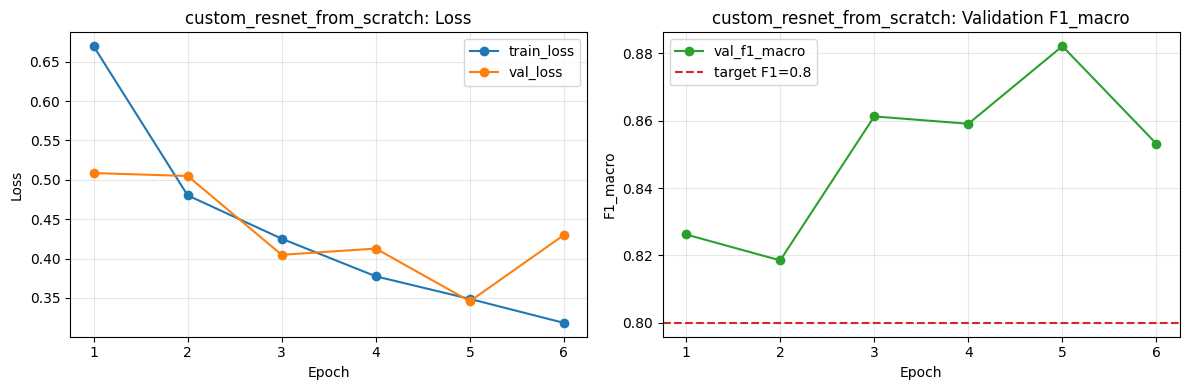

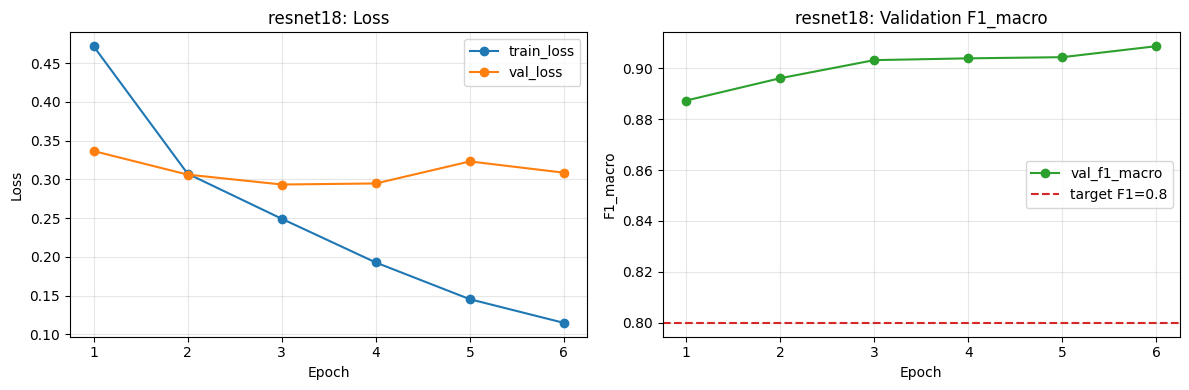

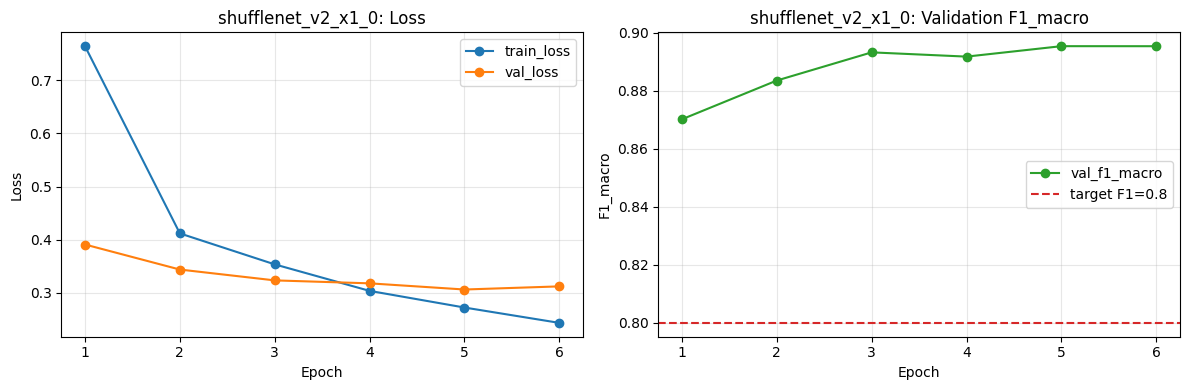

In [19]:
import matplotlib.pyplot as plt

history_map = {
    'custom_resnet_from_scratch': scratch_history_df,
    **all_histories
}

for model_name, hdf in history_map.items():
    hdf = hdf.sort_values('epoch').reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hdf['epoch'], hdf['train_loss'], marker='o', label='train_loss')
    axes[0].plot(hdf['epoch'], hdf['val_loss'], marker='o', label='val_loss')
    axes[0].set_title(f'{model_name}: Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(hdf['epoch'], hdf['val_f1_macro'], marker='o', color='tab:green', label='val_f1_macro')
    axes[1].axhline(0.8, linestyle='--', color='tab:red', label='target F1=0.8')
    axes[1].set_title(f'{model_name}: Validation F1_macro')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1_macro')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Вывод

В данном конкретном случае дообучение (обучение на основе pretrained ImageNet моделей) показало себя лучше, чем обучение с нуля, однако, если брать модели и пытаться дообучать только голову (заморозив backbone) - обучение для данной конкретной задачи получится не эффективным и не сможет пробить 0.6 по метрике f1_macro.

Однако, стоит понимать, что дообучение будет эффективнее с исходно малым датасетом, а также обеспечивает более быструю сходимость в большинстве задач классификации